# If Asset Returns Are Not Normal, What Are They?

**Cordell Tanny, CFA, FRM, FDP**  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny](https://github.com/ctanny/quant-finance-snippets)

---

In the previous notebook ([Are Asset Returns Normal?](https://github.com/ctanny/quant-finance-snippets)), we proved that asset returns are not normally distributed. Every asset class we tested rejected normality, with p-values effectively zero across the board.

That raises an important question: if returns are not normal, what distribution actually fits them?

This matters enormously for anything that involves simulating returns — Monte Carlo analysis, Value at Risk, portfolio stress testing, options pricing. If you are drawing from the wrong distribution, your results are wrong from the start.

In this notebook we will:
1. Introduce four candidate distributions and explain what makes each one a reasonable fit for financial data
2. Use two model selection criteria — AIC and BIC — to find the best fit without overfitting
3. Validate the winner using the Kolmogorov-Smirnov test
4. Run the full analysis across our six ETF universe
5. Visualize the winning distribution against the actual return data


## 1. Imports and Setup

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Same ETF universe as the previous notebook
tickers = {
    'SPY':  'US Equity',
    'TLT':  'Long Bonds',
    'GLD':  'Gold',
    'QQQ':  'Tech / Growth',
    'JNK':  'High Yield Bonds',
    'IBND': 'International Bonds',
}

## 2. Download Return Data

In [2]:
raw = yf.download(
    list(tickers.keys()),
    start='2010-01-01',
    auto_adjust=True,
    progress=False
)['Close']

returns = np.log(raw / raw.shift(1)).dropna()

print(f"Period : {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Observations: {len(returns)} trading days")

Period : 2010-05-21 to 2026-05-01
Observations: 4011 trading days


## 3. The Four Candidate Distributions

We are going to test four distributions against the data. Here is what each one is and why it belongs in this conversation.

### Normal Distribution
The classic bell curve. We already know it fails for financial returns, but we include it as a baseline. If something beats the normal distribution, we know it is doing useful work.

### Student-t Distribution
The most widely used alternative to the normal in finance. It has heavier tails controlled by a parameter called degrees of freedom. The lower the degrees of freedom, the fatter the tails. At very high degrees of freedom it converges to normal. It handles excess kurtosis well but it is symmetric — it cannot capture skewness.

### Log-Normal Distribution
Often used for asset prices rather than returns. It ensures values stay positive and captures some right-skew. It is a reasonable choice for simple returns but less ideal for log returns, which can be negative.

### Johnson SU Distribution
This is the one most practitioners have never heard of, and it is often the best fit for financial returns. It has four parameters that independently control the mean, standard deviation, skewness, and kurtosis. Unlike the Student-t, it handles asymmetric distributions. It is more flexible than any of the others.

The SU stands for unbounded — the distribution can take any real value, which makes it well suited for returns data.

## 4. How Do We Pick the Best Fit? AIC and BIC

When fitting distributions, more flexible models will always fit the data better in-sample. A distribution with four parameters will beat one with two parameters almost every time — but that does not mean it is actually a better model. It might just be memorizing the noise.

This is the overfitting problem. We need a way to reward goodness of fit while penalizing unnecessary complexity.

Two information criteria do exactly this:

**AIC (Akaike Information Criterion)**  
AIC = 2k - 2 * log-likelihood  
where k is the number of parameters and log-likelihood measures how well the distribution fits the data.  
Lower AIC is better. The penalty term 2k discourages adding parameters that do not meaningfully improve the fit.

**BIC (Bayesian Information Criterion)**  
BIC = k * log(n) - 2 * log-likelihood  
where n is the number of observations.  
BIC penalizes complexity more heavily than AIC, especially on large samples. Lower BIC is better.

We also run the **Kolmogorov-Smirnov test** as a final validation. This compares the fitted distribution's cumulative distribution function against the actual data. A higher p-value means the fitted distribution is a more plausible match.

> **Rule of thumb**: Use AIC and BIC together. When they agree, you can be confident in the winner. When they disagree, prefer BIC on large samples.

## 5. The Best Fit Function

In [3]:
def calculate_aic_bic(n, log_likelihood, num_params):
    """
    Calculate AIC and BIC for a fitted distribution.

    Parameters
    ----------
    n             : number of observations
    log_likelihood: sum of log-pdf values under the fitted distribution
    num_params    : number of parameters in the distribution

    Returns
    -------
    aic, bic : float
    """
    aic = 2 * num_params - 2 * log_likelihood
    bic = np.log(n) * num_params - 2 * log_likelihood
    return aic, bic


def find_best_distribution(returns, distributions):
    """
    For each asset, fit every candidate distribution and select the best
    based on KS test p-value and AIC/BIC.

    Parameters
    ----------
    returns       : pd.DataFrame, one column per asset
    distributions : list of scipy.stats continuous distribution objects

    Returns
    -------
    pd.DataFrame with best fit distribution and key statistics per asset
    """
    results = []

    for column in returns.columns:
        r = returns[column].dropna().values
        best = {'ks_p': -1, 'aic': np.inf, 'bic': np.inf,
                'name': '', 'params': None}

        for dist in distributions:
            try:
                # Fit distribution to data
                params = dist.fit(r)

                # Log-likelihood
                log_ll = np.sum(dist.logpdf(r, *params))

                # KS test
                ks_stat, ks_p = stats.kstest(r, dist.name, args=params)

                # AIC and BIC
                aic, bic = calculate_aic_bic(len(r), log_ll, len(params))

                # Select best: prioritise KS p-value, break ties with AIC
                if (ks_p > best['ks_p'] or
                        (np.isclose(ks_p, best['ks_p']) and aic < best['aic'])):
                    best = {'ks_p': ks_p, 'aic': aic, 'bic': bic,
                            'name': dist.name, 'params': params,
                            'dist': dist}

            except Exception:
                continue

        results.append({
            'ETF'             : column,
            'Asset Class'     : tickers[column],
            'Best Fit'        : best['name'],
            'KS p-value'      : round(best['ks_p'], 4),
            'AIC'             : round(best['aic'], 1),
            'BIC'             : round(best['bic'], 1),
            '_params'         : best['params'],
            '_dist'           : best.get('dist'),
        })

    return pd.DataFrame(results)


# The four candidate distributions
distributions = [
    stats.norm,      # Normal — our baseline
    stats.t,         # Student-t — fat tails, symmetric
    stats.lognorm,   # Log-normal — common in finance
    stats.johnsonsu, # Johnson SU — fat tails AND skewness
]

results_df = find_best_distribution(returns, distributions)

# Display results without internal columns
display_df = results_df.drop(columns=['_params', '_dist']).set_index('ETF')
print(display_df.to_string())

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6921: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


              Asset Class   Best Fit  KS p-value      AIC      BIC
ETF                                                               
GLD                  Gold  johnsonsu      0.9800 -25873.0 -25847.8
IBND  International Bonds  johnsonsu      0.0372 -30097.6 -30072.4
JNK      High Yield Bonds  johnsonsu      0.2640 -32693.9 -32668.8
QQQ         Tech / Growth  johnsonsu      0.1964 -24274.4 -24249.2
SPY             US Equity  johnsonsu      0.2096 -26122.1 -26096.9
TLT            Long Bonds  johnsonsu      0.2523 -26250.9 -26225.7


## 6. Visualizing the Best Fit

Numbers tell us which distribution wins. The chart shows us why.

We overlay the best fitting distribution on the actual return histogram for each ETF. Pay close attention to the tails — that is where the difference between a good and a bad distribution choice shows up most clearly.

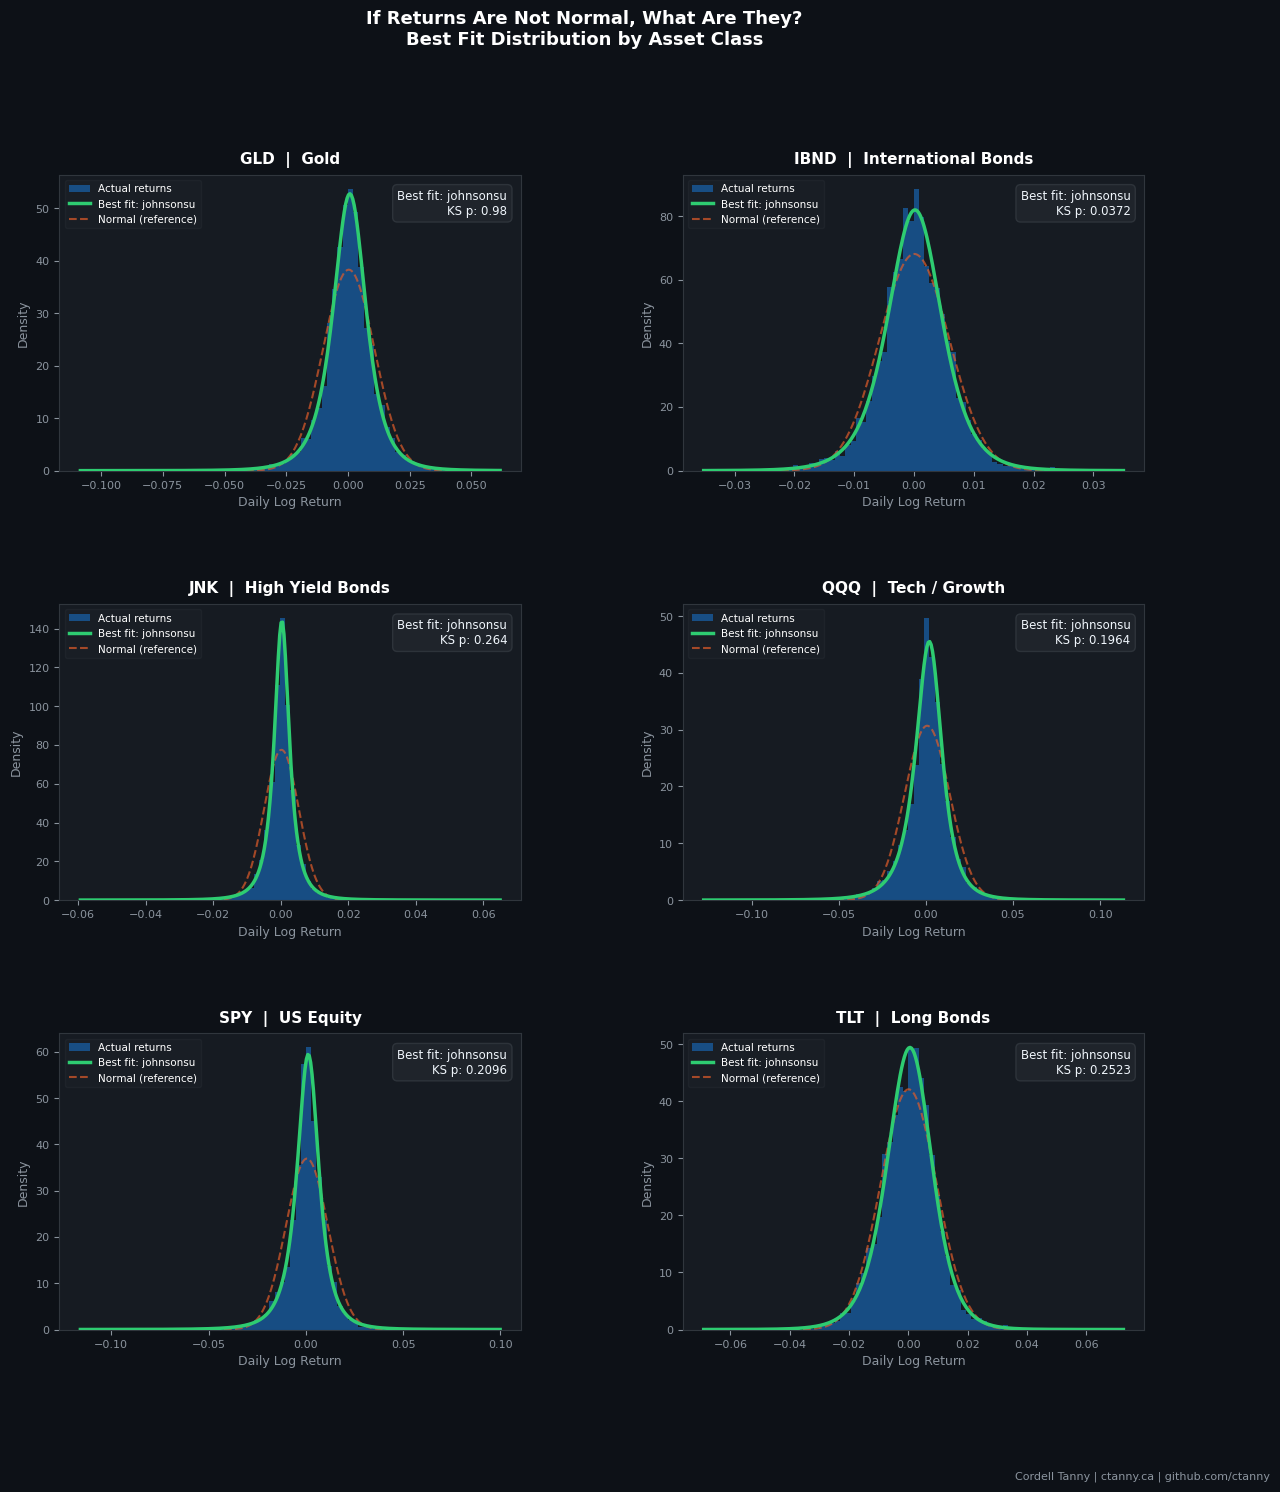

In [4]:
fig = plt.figure(figsize=(14, 15))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

for i, row in results_df.iterrows():
    ax  = fig.add_subplot(gs[i // 2, i % 2])
    ax.set_facecolor('#161b22')

    ticker = row['ETF']
    label  = row['Asset Class']
    dist   = row['_dist']
    params = row['_params']
    r      = returns[ticker].dropna()
    mu, sigma = r.mean(), r.std()

    # Actual return histogram
    ax.hist(r, bins=80, density=True, color='#185FA5',
            alpha=0.75, label='Actual returns', zorder=2)

    # Best fit distribution overlay
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, dist.pdf(x, *params),
            color='#2ECC71', linewidth=2.5,
            label=f'Best fit: {row["Best Fit"]}', zorder=4)

    # Normal overlay for comparison
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color='#E05C2A', linewidth=1.5, linestyle='--',
            label='Normal (reference)', zorder=3, alpha=0.7)

    ax.set_title(f'{ticker}  |  {label}',
                 color='white', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Daily Log Return', color='#8b949e', fontsize=9)
    ax.set_ylabel('Density',          color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e',  labelsize=8)
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363d')

    ax.text(0.97, 0.95,
            f'Best fit: {row["Best Fit"]}\nKS p: {row["KS p-value"]}',
            transform=ax.transAxes, color='#f0f6fc', fontsize=8.5,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#21262d',
                      edgecolor='#30363d', alpha=0.9))

    ax.legend(fontsize=7.5, framealpha=0.3, labelcolor='white',
              facecolor='#21262d', edgecolor='#30363d')

fig.suptitle('If Returns Are Not Normal, What Are They?\nBest Fit Distribution by Asset Class',
             color='white', fontsize=13, fontweight='bold', y=0.99)

plt.figtext(0.99, 0.01,
            'Cordell Tanny | ctanny.ca | github.com/ctanny',
            ha='right', color='#8b949e', fontsize=8)

plt.savefig('distribution_fitting.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 7. Interpreting the Results

Johnson SU wins across every single asset class. Not a single asset
was better described by the normal distribution, the Student-t,
or the log-normal.

This is not a surprise once you think about it. Johnson SU has four
parameters that independently fit the mean, standard deviation,
skewness, and kurtosis of the data. The other distributions are
constrained in ways that financial return data simply does not
respect. Student-t cannot capture skewness. Log-normal cannot
handle negative returns cleanly. Normal fails on both counts.

Looking at the numbers more closely:

**Gold (GLD)** is the standout result. A KS p-value of 0.98 means
the Johnson SU distribution fits gold's returns almost perfectly.
Of all six assets, gold's return distribution is the most
well-behaved once you allow for skewness and fat tails.

**International Bonds (IBND)** is the weakest fit with a KS
p-value of 0.037, which technically falls below the standard
0.05 threshold. Johnson SU is still the best of the four
candidates, but it tells you that IBND's return distribution
has characteristics that none of these four distributions
capture cleanly. This is worth keeping in mind if you plan
to simulate international bond returns.

**The AIC and BIC numbers** tell a consistent story across all
six assets. The lower the value, the better the fit relative
to the number of parameters used. Johnson SU earns its four
parameters every time.

**The runtime warning** about an invalid log value is a known
scipy quirk when fitting the log-normal distribution to data
that contains values close to zero. It does not affect the
Johnson SU results and can be safely ignored.

The practical takeaway is straightforward: if you are running
any kind of simulation that draws from a return distribution,
Johnson SU is your starting point. Not normal. Not Student-t.
Johnson SU.

## 8. Key Takeaways

1. **Normal distribution loses every time.** We already knew this from the previous notebook but the AIC and BIC numbers confirm it rigorously.

2. **Johnson SU is the most flexible tool in this set.** Its four parameters let it independently fit the mean, standard deviation, skewness, and kurtosis of the data. For assets with both fat tails and skewness — which is most of them — this flexibility matters.

3. **Student-t is a reasonable choice when skewness is small.** If an asset's return distribution is roughly symmetric but fat-tailed, Student-t is simpler and nearly as accurate. Always check the skewness first.

4. **AIC and BIC are your model selection tools.** Do not just pick the distribution that fits best in-sample. Use information criteria to penalize complexity and avoid overfitting.

5. **Practical implication for simulation:** When you run a Monte Carlo simulation on a portfolio, the distribution you draw from matters enormously. Drawing from a normal distribution will underestimate the frequency of large losses. Drawing from a well-fitted Johnson SU or Student-t distribution will produce far more realistic tail scenarios.

---

**What comes next:**  
Now that we know which distribution fits our data, the next step is to use it in a Monte Carlo simulation — and to do it correctly. That is the subject of the next notebook.

---

*Cordell Tanny, CFA, FRM, FDP*  
[ctanny.ca](https://ctanny.ca) | [github.com/ctanny](https://github.com/ctanny/quant-finance-snippets)  
*Questions or ideas? Connect on LinkedIn.*